In [ ]:
import os
import torch
from torch import nn
import torch.distributed as dist
from torch.utils.data import WeightedRandomSampler
import torch.optim as optim

import scanpy as sc

import pandas as pd
import numpy as np

from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split

import anndata as ad
from anndata.experimental import AnnCollection
from anndata.experimental.pytorch import AnnLoader

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cpu device


In [ ]:
p = '/data/users/isanor/kand/data/conv_data/'

#print(os.getcwd())
#print(os.listdir(p))

f = 'Vasculature_cells.h5ad'
pf = os.path.join(p, f)
print(os.path.exists(pf))
adata1 = ad.read_h5ad(pf, backed="r")

f = 'Immune_cells.h5ad'
pf = os.path.join(p, f)
print(os.path.exists(pf))
adata2 = ad.read_h5ad(pf, backed="r")

True
True


In [ ]:
print(adata1)
#print(adata1.layers['logcounts'][1,:])
#print(adata1.X[1,:])

AnnData object with n_obs × n_vars = 17974 × 33538 backed at '/data/users/isanor/kand/data/conv_data/Vasculature_cells.h5ad'
    obs: 'cell_type_high_resolution', 'subject', 'ident'
    obsm: 'X_umap'
    layers: 'logcounts'


In [ ]:
p = '/data/users/isanor/kand/data/conv_data/'
l = ['Vasculature_cells.h5ad', 'Oligodendrocytes.h5ad', 'Excitatory_neurons_set1.h5ad', 'Immune_cells.h5ad', 'Excitatory_neurons_set3.h5ad', 'Inhibitory_neurons.h5ad', 'OPCs.h5ad', 'Astrocytes.h5ad', 'Excitatory_neurons_set2.h5ad']

def correct_nr_cells(p,l):
    count = 0
    for f in l:
        print(f'Reading: {f}...')
        path = os.path.join(p, f)

        # backed mode should make reading the data faster as we don't read everyting into memory,
        # still takes a while tho :/
        info = ad.read_h5ad(path, backed="r") 
        print('Nr cells: {info.n_obs}, nr genes: {info.n_vars}, total cells so far: {count}')
        count += info.n_obs

    print(f'Total: {count}, should be 2359994')
    assert count == 2_359_994, "Mismatch of nr cells in dataset and in article"

# Takes about 12 mins 
# correct_nr_cells(p,l)
# IS CORRECT! :)

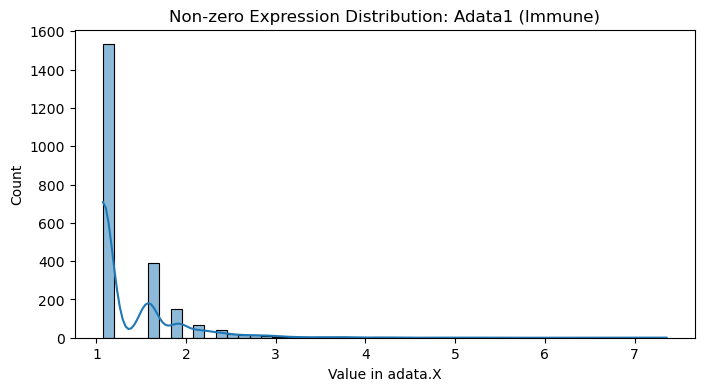

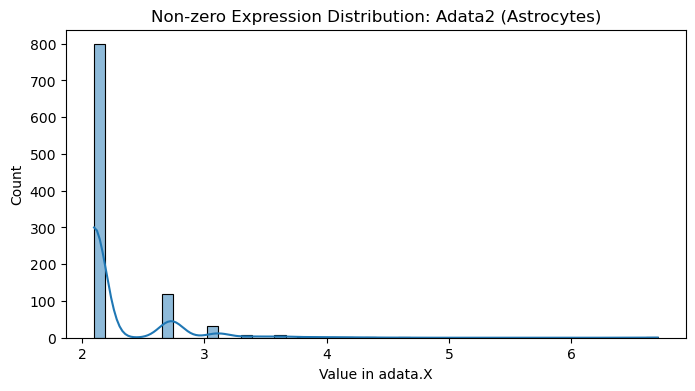

In [ ]:
# Load data into memory
adata1 = adata1.to_memory()
adata2 = adata2.to_memory()

def plot_distribution(ad, title):
    # Take the first cell and exclude zeros to see the expression curve
    first_cell = ad.X[0, :].copy()
    if hasattr(first_cell, "toarray"): first_cell = first_cell.toarray()
    
    nonzero_vals = first_cell[first_cell > 0]
    
    plt.figure(figsize=(8, 4))
    sns.histplot(nonzero_vals, bins=50, kde=True)
    plt.title(f"Non-zero Expression Distribution: {title}")
    plt.xlabel("Value in adata.X")
    plt.show()

# Use log normalized counts (the ones precomputed by Mathys et al. )
# NOTE: Do we need to recalculate this if we change the underlying data?
adata1.X = adata1.layers['logcounts'].astype('float32')
adata2.X = adata2.layers['logcounts'].astype('float32')

plot_distribution(adata1, "Adata1 (Immune)")
plot_distribution(adata2, "Adata2 (Astrocytes)")

In [ ]:
### Keep only highly variable genes (HVGs)

# Note: expects log data
sc.pp.highly_variable_genes(adata1, n_top_genes=2000)
sc.pp.highly_variable_genes(adata2, n_top_genes=2000)

genes1 = adata1.var_names[adata1.var.highly_variable]
genes2 = adata2.var_names[adata2.var.highly_variable]

print(genes1)

# Intersection of the sets
common_hvgs = list(set(genes1) & set(genes2))
adata1_sub = adata1[:, common_hvgs].copy()
adata2_sub = adata2[:, common_hvgs].copy()

In [ ]:
### Pseudobulk

# Create the pseudobulk object
pbulk1 = sc.get.aggregate(
    adata1_sub, 
    by=['subject', 'cell_type_high_resolution'], 
    func='sum'
)

pbulk2 = sc.get.aggregate(
    adata2_sub, 
    by=['subject', 'cell_type_high_resolution'], 
    func='sum'
)

pbulk1.X = pbulk1.layers['sum'].copy()
pbulk2.X = pbulk2.layers['sum'].copy()


In [52]:
# only include genes with more than 10 observations
pbulk1 = pbulk1[pbulk1.obs['n_obs_aggregated'] >= 10].copy()
pbulk2 = pbulk2[pbulk2.obs['n_obs_aggregated'] >= 10].copy()

# shows if there are any columns included in only one of the sets
set(pbulk1.obs.columns) ^ set(pbulk2.obs.columns)

set()

In [53]:
# Slice before normalization
print(pbulk1.X[:2,:5])

[[ 3.40221977  0.          7.24505019 11.96439254  0.        ]
 [ 3.07355213  7.638502    2.54716527  5.02632022  0.        ]]


In [ ]:
### Normalize data again after selecting HVGs and pseudobulking 


'''
"Normalization is a necessary step in the analysis of single-cell RNA sequencing data in order to remove the impact of technical variations in the analysis count data, while preserving as much as possible the biological differences between cells. Several bulk RNA sequencing analysis methods have been applied to scRNA-seq analysis, the most classic approach for normalization is ‘counts per million’ (CPM). It removes the technical biases by applying size factor that is proportional to the count depth of each sample." -https://academic.oup.com/bib/article/23/1/bbab345/6361043?login=true#327078564
'''

for pbulk in [pbulk1, pbulk2]:
    # Normalizes counts per pseudobulk sample
    # There are possible options, e.g. exclude highly expressed genes from computation

    # Using Counts per million
    sc.pp.normalize_total(pbulk, exclude_highly_expressed=True, target_sum=1e6)

    # Especially useful if range is large?
    sc.pp.log1p(pbulk)

    # Scaling centers genes at 0
    # Helps model learn *relative* expression
    sc.pp.scale(pbulk)

# Slice after normalization
print(pbulk1.X[:2,:5])

[[ 0.74451526 -0.89341399  0.50446152  0.11104179 -0.05596383]
 [ 0.94527411  1.48221378  0.46446743  0.13070597 -0.05596383]]


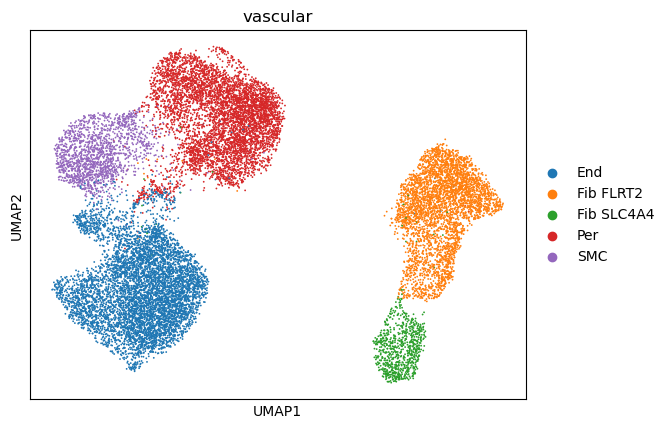

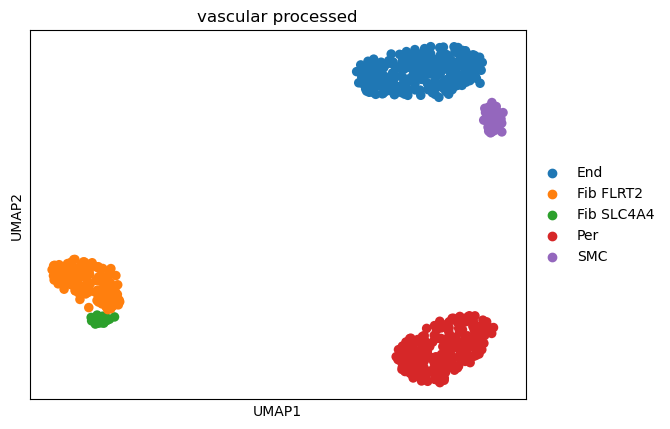

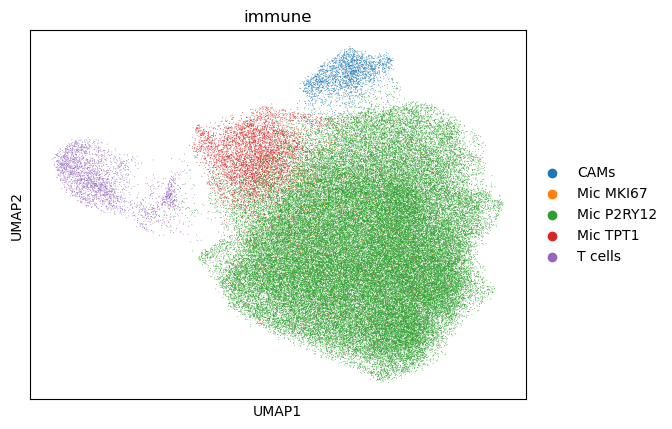

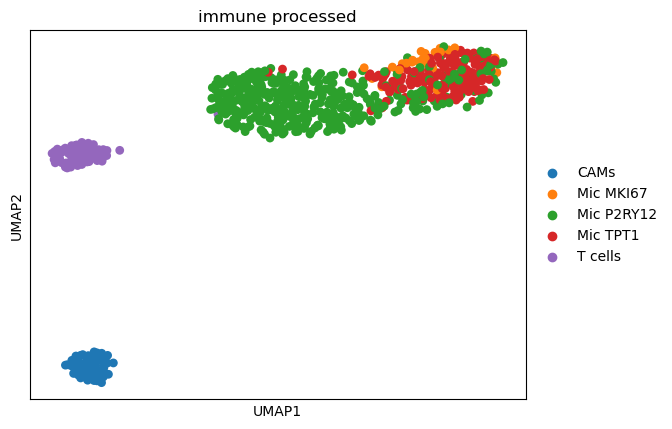

In [58]:
def draw_umaps():
    sc.tl.pca(adata1, svd_solver='arpack')
    sc.pp.neighbors(adata1, n_neighbors=20, n_pcs = 30)
    sc.tl.umap(adata1)

    sc.tl.pca(adata2, svd_solver='arpack')
    sc.pp.neighbors(adata2, n_neighbors=20, n_pcs = 30)
    sc.tl.umap(adata2)

    sc.tl.pca(pbulk1, svd_solver='arpack')
    sc.pp.neighbors(pbulk1, n_neighbors=20, n_pcs = 30)
    sc.tl.umap(pbulk1)

    sc.tl.pca(pbulk2, svd_solver='arpack')
    sc.pp.neighbors(pbulk2, n_neighbors=20, n_pcs = 30)
    sc.tl.umap(pbulk2)

    sc.pl.umap(adata1, title="vascular", color=['cell_type_high_resolution'])
    sc.pl.umap(pbulk1, title="vascular processed", color=['cell_type_high_resolution'])

    sc.pl.umap(adata2, title="immune", color=['cell_type_high_resolution'])
    sc.pl.umap(pbulk2, title="immune processed", color=['cell_type_high_resolution'])

draw_umaps()

In [59]:
p = '/data/users/isanor/kand/data/supplementary_data/'
f = 'individual_metadata_deidentified.tsv'
print(os.path.exists(p+f))
metadata = pd.read_csv(p+f,sep='\t')

AD_status_lbl = 'Pathologic_diagnosis_of_AD'
md_sel = metadata[['subject', AD_status_lbl]]

True


In [60]:
# Annotate the data with the disease status of the subject

# floats for logits loss
# int for BCE loss
md_sel[AD_status_lbl].replace(to_replace='yes', value=1.0, inplace=True)
md_sel[AD_status_lbl].replace(to_replace='no', value=0.0, inplace=True)

print(md_sel)

# create map with subject as key, AD status as value
status_map = dict(zip(md_sel['subject'], md_sel[AD_status_lbl]))

for dataset in [pbulk1, pbulk2]:
    # 1. Extract subjects and force to string
    subjects = dataset.obs['subject'].astype(str).values

    new_statuses = [str(status_map.get(s)) for s in subjects]
    
    dataset.obs['AD_status'] = new_statuses
    
    # 4. Now convert to category (this should no longer conflict)
    dataset.obs['AD_status'] = dataset.obs['AD_status'].astype('category')

print(pbulk1.obs['AD_status'].head())

          subject  Pathologic_diagnosis_of_AD
0    ROSMAP-10132                         1.0
1    ROSMAP-10643                         1.0
2    ROSMAP-10859                         1.0
3    ROSMAP-12078                         1.0
4    ROSMAP-12256                         1.0
..            ...                         ...
422  ROSMAP-98582                         0.0
423  ROSMAP-98683                         1.0
424  ROSMAP-99419                         0.0
425  ROSMAP-99585                         1.0
426  ROSMAP-99981                         1.0

[427 rows x 2 columns]
ROSMAP-10132_End    1.0
ROSMAP-10132_Per    1.0
ROSMAP-10132_SMC    1.0
ROSMAP-10643_End    1.0
ROSMAP-10643_Per    1.0
Name: AD_status, dtype: category
Categories (2, object): ['0.0', '1.0']


/tmp/ipykernel_435412/3431304783.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  md_sel[AD_status_lbl].replace(to_replace='yes', value=1.0, inplace=True)
/tmp/ipykernel_435412/3431304783.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  md_sel[AD_status_lbl].replace(to_replace='yes', value=1.0, inplace=True)
/tmp/ipykernel_435412/3431304

In [61]:
### Encoding

# Encoding by general cell type
cell_type_low_res_encoder = OneHotEncoder(sparse_output=False, dtype=np.float32)

# Encoding by fine-grained cell type
cell_type_high_res_encoder = OneHotEncoder(sparse_output=False, dtype=np.float32)

# Encode disease status
status_encoder = LabelEncoder()

converters = {
    'obs': {
        # One-hot encode the covariates
        'cell_type_low_res': lambda x: cell_type_low_res_encoder.transform(x.to_numpy()[:, None]),
        'cell_type_high_res': lambda x: cell_type_high_res_encoder.transform(x.to_numpy()[:, None]),
        
        # Label encode the target (AD_status)
        'AD_status': status_encoder.transform
    }
}

In [62]:
# We can join several data sets together in a collection

# This is the way to do it with a large dataset
collection = AnnCollection(
    {'vasculature':pbulk1, 'immune':pbulk2}, # labels for subsets
    join_vars='outer', # keep all records
    label='cell_type_low_res', # in this case vasculature, immune
    convert=converters, # do encoding when creating the collection
    indices_strict=False # in case there exist cells with same ID (unlikely here?)
)

# for brevity
collection.obs.rename(columns={'cell_type_high_resolution': 'cell_type_high_res'}, inplace=True)

print(collection)

print(collection.obs['AD_status'].head())

AnnCollection object with n_obs × n_vars = 1388 × 446
  constructed from 2 AnnData objects
    view of obsm: 'X_pca', 'X_umap'
    view of layers: 'sum'
    obs: 'subject', 'cell_type_high_res', 'n_obs_aggregated', 'AD_status', 'cell_type_low_res'
ROSMAP-10132_End    1.0
ROSMAP-10132_Per    1.0
ROSMAP-10132_SMC    1.0
ROSMAP-10643_End    1.0
ROSMAP-10643_Per    1.0
Name: AD_status, dtype: category
Categories (2, object): ['0.0', '1.0']


In [63]:
cell_type_low_res_encoder.fit(collection.obs["cell_type_low_res"].to_numpy()[:,None])

cell_type_high_res_encoder.fit(collection.obs["cell_type_high_res"].to_numpy()[:,None])

status_encoder.fit(collection.obs["AD_status"])


LabelEncoder()

In [64]:
### Inspecting the combined data!

# show the number of AD vs non-AD subjects
subject_counts = collection.obs.drop_duplicates('subject')['AD_status'].value_counts()
print("Number of unique subjects:")
print(subject_counts)

# See the total distribution of cells per disease status
print(f'\n Distribution of cells per disease status')
print(collection.obs['AD_status'].value_counts())

# show how many cells exist of each high res cell type for each subject
#count_table = pd.crosstab(collection.obs['subject'], collection.obs['cell_type_high_res'])
#print(count_table)

# show how many cells exist of each low res cell type for each subject
#count_table = pd.crosstab(collection.obs['subject'], collection.obs['cell_type_low_res'])
#print(count_table)

# show how many cells exist for each low res cell type AD vs non-AD
count_table = pd.crosstab(collection.obs['AD_status'], collection.obs['cell_type_low_res'])
print(f'\nCells per general cell type, AD vs non-AD')
print(count_table)

# Check that distribution of cell types are not skewed for AD vs. non-AD
print(f'\nDistribution of high res celltypes AD vs non-AD')
dist_pct_col = pd.crosstab(
    collection.obs['AD_status'], 
    collection.obs['cell_type_high_res'], 
    normalize='columns') * 100

print(dist_pct_col.round(2).astype(str) + '%')

# Check that distribution of cell types are not skewed for AD vs. non-AD
print(f'\nDistribution of high res celltypes AD vs non-AD')
dist_pct_row = pd.crosstab(
    collection.obs['AD_status'], 
    collection.obs['cell_type_high_res'], 
    normalize='index') * 100

print(dist_pct_row.round(2).astype(str) + '%')

common_cells = set(adata1.obs_names).intersection(set(adata2.obs_names))
print(f"Number of overlapping cell IDs: {len(common_cells)}")


Number of unique subjects:
AD_status
1.0    232
0.0    184
Name: count, dtype: int64

 Distribution of cells per disease status
AD_status
1.0    753
0.0    635
Name: count, dtype: int64

Cells per general cell type, AD vs non-AD
cell_type_low_res  vasculature  immune
AD_status                             
0.0                        289     346
1.0                        350     403

Distribution of high res celltypes AD vs non-AD
cell_type_high_res    CAMs     End Fib FLRT2 Fib SLC4A4 Mic MKI67 Mic P2RY12  \
AD_status                                                                      
0.0                 58.21%  41.22%     50.0%     68.42%    46.43%     44.34%   
1.0                 41.79%  58.78%     50.0%     31.58%    53.57%     55.66%   

cell_type_high_res Mic TPT1     Per     SMC T cells  
AD_status                                            
0.0                  42.77%  43.81%  51.28%   52.5%  
1.0                  57.23%  56.19%  48.72%   47.5%  

Distribution of high res cel

cell_type_high_res   CAMs     End Fib FLRT2 Fib SLC4A4 Mic MKI67 Mic P2RY12  \
AD_status                                                                     
0.0                 6.14%  15.91%     9.92%      2.05%     2.05%     28.98%   
1.0                 3.72%  19.12%     8.37%       0.8%     1.99%     30.68%   

cell_type_high_res Mic TPT1     Per    SMC T cells  
AD_status                                           
0.0                  10.71%  14.49%  3.15%   6.61%  
1.0                  12.08%  15.67%  2.52%   5.05%  
Number of overlapping cell IDs: 0


In [65]:
### Super basic loader
### Further below: split into train and test set

# Create AnnLoader directly from collection
# Divides the data into batches
loader = AnnLoader(collection, batch_size=250, shuffle=True)

# Get first batch
batch = next(iter(loader))

# Check batch structure
assert hasattr(batch, 'X'), "Batch should have X attribute"
assert hasattr(batch, 'obs'), "Batch should have obs attribute"
assert hasattr(batch, 'obsm'), "Batch should have obsm attribute"
assert isinstance(batch.X, torch.Tensor), "X should be torch.Tensor"

print(f"Number of batches: {len(loader)}")
print(f"Batch X shape: {batch.X.shape}")
print(f"Batch X type: {type(batch.X)}")
print(f"Batch obs keys: {list(batch.obs.keys())}")

Number of batches: 6
Batch X shape: torch.Size([250, 446])
Batch X type: <class 'torch.Tensor'>
Batch obs keys: ['subject', 'cell_type_high_res', 'n_obs_aggregated', 'AD_status', 'cell_type_low_res']


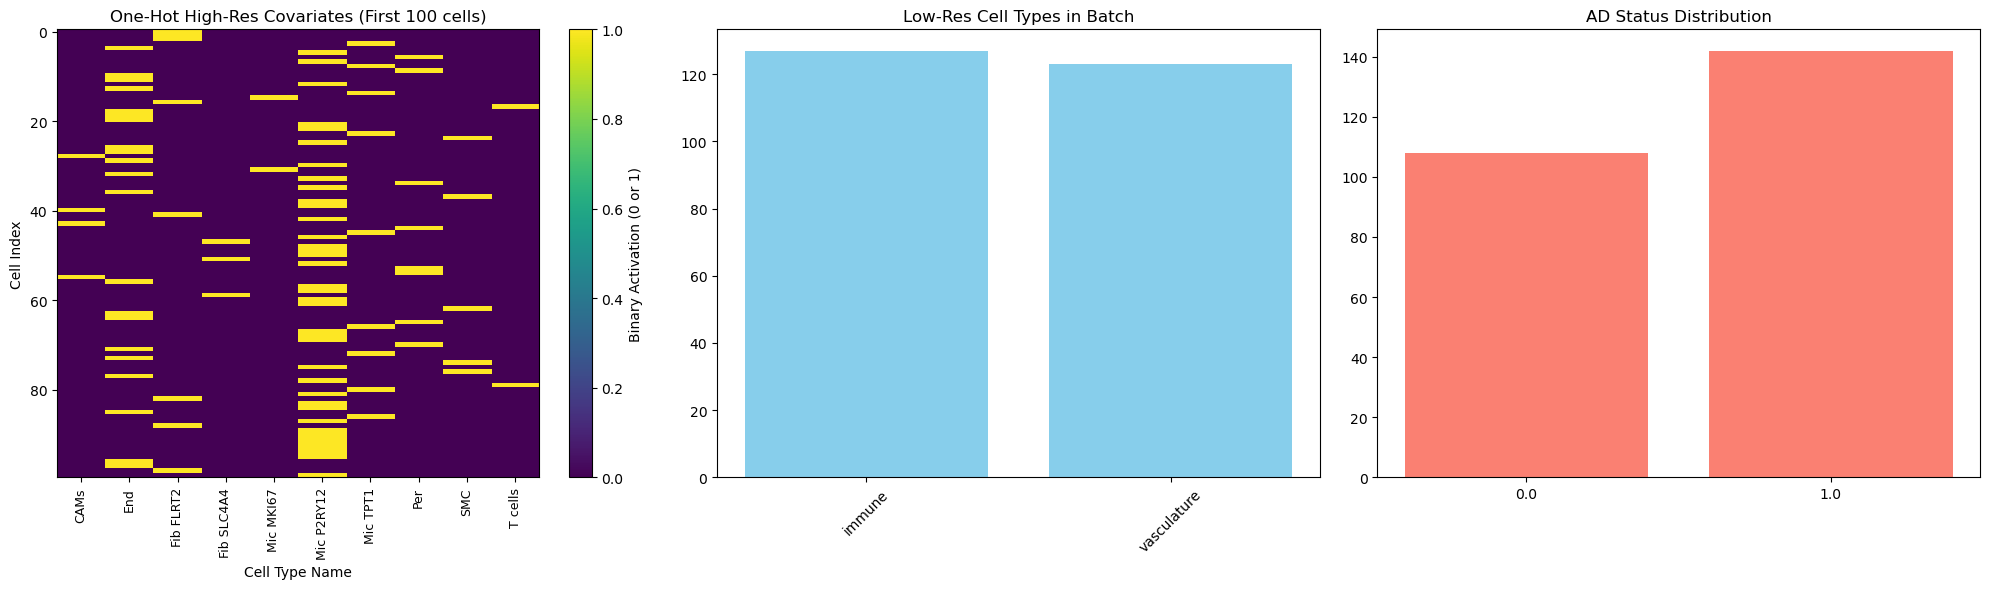

In [66]:
# Adapted from (cell 24)
# https://www.kaggle.com/code/fiveflowerstarfish/anndata-basics-and-pytorch-integration#VAE-Model-Implementation

def draw_panels(batch, n=50):
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

    # --- Panel 1: One-Hot Encoded Covariates with Names ---
    sample_highres = batch.obs['cell_type_high_res'][:n].cpu().numpy()
    im1 = ax1.imshow(sample_highres, cmap='viridis', aspect='auto')

    # Get the names from the encoder categories
    high_res_names = cell_type_high_res_encoder.categories_[0]

    ax1.set_title(f'One-Hot High-Res Covariates (First {n} cells)')
    ax1.set_ylabel('Cell Index')
    ax1.set_xlabel('Cell Type Name')

    # Set ticks to match the number of categories
    ax1.set_xticks(np.arange(len(high_res_names)))
    ax1.set_xticklabels(high_res_names, rotation=90, fontsize=9)

    plt.colorbar(im1, ax=ax1, label='Binary Activation (0 or 1)')

    # --- Panel 2: Low-Res Cell Type Distribution ---
    lowres_data = batch.obs['cell_type_low_res'].cpu().numpy()
    lowres_indices = np.argmax(lowres_data, axis=1)
    lowres_counts = pd.Series(lowres_indices).value_counts().sort_index()

    ax2.bar(lowres_counts.index, lowres_counts.values, color='skyblue')
    ax2.set_title('Low-Res Cell Types in Batch')
    ax2.set_xticks(lowres_counts.index)
    ax2.set_xticklabels(cell_type_low_res_encoder.categories_[0], rotation=45)

    # --- Panel 3: AD Status ---
    status_data = batch.obs['AD_status'].cpu().numpy()
    status_counts = pd.Series(status_data).value_counts().sort_index()

    ax3.bar(status_counts.index, status_counts.values, color='salmon')
    ax3.set_title('AD Status Distribution')
    ax3.set_xticks(status_counts.index)
    ax3.set_xticklabels(status_encoder.classes_)

    plt.tight_layout()
    plt.show()

draw_panels(batch, n=100)

- We can see that Mic P2RY12 is a very common cell type, while others, such as Fib SLC4A4 are rare.
- We can see that vasculature cells are less common than immune cells
- We can see that AD and non-AD subjects are equally distributed

In [67]:
### Train test split

indices = np.arange(collection.n_obs)

train_size = 0.8
train_idx, test_idx = train_test_split(
    indices,
    test_size=1-train_size,
    stratify=collection.obs['cell_type_high_res'],
    random_state = 34
)

train_obs = collection.obs.iloc[train_idx]
train_cell_types = train_obs['cell_type_high_res'].values
train_type_counts = pd.Series(train_cell_types).value_counts()

In [68]:
from sklearn.model_selection import GroupShuffleSplit

# Create a unique ID for each subject (not row)
# We also need their disease status for stratification
subject_metadata = collection.obs[['subject', 'AD_status']].drop_duplicates()

# This ensures that all rows with the same 'subject' stay together
gss = GroupShuffleSplit(n_splits=1, train_size=0.8, random_state=34)

# Perform the split
# We pass the 'AD_status' to the groups context to maintain balance
train_idx, test_idx = next(gss.split(
    X=collection.obs, 
    y=collection.obs['AD_status'], 
    groups=collection.obs['subject']
))

# Create your adata objects
train_adata = collection[train_idx]
test_adata = collection[test_idx]

# 5. Verify the results
print(f"Train Subjects: {train_adata.obs['subject'].nunique()}")
print(f"Test Subjects: {test_adata.obs['subject'].nunique()}")

Train Subjects: 332
Test Subjects: 84


In [69]:
### For training set: 
# loader that takes into account the relative frequencies of sample types

# list of cell types in training set
cell_types = collection.obs.iloc[train_idx]['cell_type_high_res'].values

# frequency of each cell type
type_counts = pd.Series(cell_types).value_counts()

weights = np.zeros(len(cell_types))

for i, c_type in enumerate(cell_types):
    # TODO: inversely proportional to frequency in training set, may want to refine
    weights[i] = len(train_idx) / type_counts[c_type]
    #print(f'{c_type:<12} {type_counts[c_type]: 7} {weights[i]: 8.2f}')

sampler = WeightedRandomSampler(
    weights=weights, 
    num_samples=len(train_idx), # default choice is to use the length of the dataset
    replacement=True # can draw the same sample several times
    )


train_loader = AnnLoader(train_adata, batch_size=128, shuffle=False)
test_loader = AnnLoader(test_adata, batch_size=128, shuffle=False)

batch = next(iter(train_loader))

In [70]:
print(collection.obs.iloc[train_idx].value_counts())
print(collection.obs.iloc[test_idx].value_counts())
print(collection.obs.iloc[test_idx]['AD_status'].value_counts())

print(11093 / (11093+9280) * 100)
print(9280 / (11093+9280) * 100)


subject       cell_type_high_res  n_obs_aggregated  AD_status  cell_type_low_res
ROSMAP-10132  End                 49                1.0        vasculature          1
              Mic P2RY12          200               1.0        immune               1
              Mic TPT1            13                1.0        immune               1
              Per                 20                1.0        vasculature          1
              SMC                 122               1.0        vasculature          1
                                                                                   ..
ROSMAP-99585  Fib FLRT2           10                1.0        vasculature          1
              Mic P2RY12          141               1.0        immune               1
ROSMAP-99981  End                 24                1.0        vasculature          1
              Mic P2RY12          196               1.0        immune               1
              Mic TPT1            11                1.0    

In [71]:
#draw_panels(batch, n=100)

In [72]:
class AD_classifier(nn.Module):
    def __init__(self, input_dim):
        super(AD_classifier, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, 1), # Single output for binary classification
        )
    
    def forward(self, x):
        return self.network(x)

In [73]:
model = AD_classifier(input_dim=collection.n_vars)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [74]:
import warnings
warnings.filterwarnings('ignore')

epochs = 25
for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    # training loop
    for batch in train_loader:
        # Extracting gene expression and AD status
        X_batch = torch.tensor(batch.X, dtype=torch.float32).to(device)
        y_batch = batch.obs['AD_status'].float().to(device)
        
        # forward pass
        outputs = model(X_batch).squeeze()
        loss = criterion(outputs, y_batch.float())

        # backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # validation loop
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for batch_val in test_loader:
            # Unpacking the data
            X_val = torch.tensor(batch_val.X, dtype=torch.float32).to(device)
            y_val = batch_val.obs['AD_status'].float().to(device)
            
            # make prediction
            outputs = model(X_val).squeeze()
            loss = criterion(outputs, y_val.float())
            val_loss += loss.item()

            predicted = (outputs > 0.5).float()
            total += y_val.size(0)
            correct += (predicted == y_val).sum().item()

    avg_train = train_loss / len(train_loader)
    avg_val = val_loss / len(test_loader)
    accuracy = 100 * correct / total

    print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f} | Val Acc: {accuracy:.2f}%")

Epoch [1/25] | Train Loss: 0.6935 | Val Loss: 0.6870 | Val Acc: 42.29%
Epoch [2/25] | Train Loss: 0.6743 | Val Loss: 0.6820 | Val Acc: 41.11%
Epoch [3/25] | Train Loss: 0.6646 | Val Loss: 0.6779 | Val Acc: 40.71%
Epoch [4/25] | Train Loss: 0.6506 | Val Loss: 0.6744 | Val Acc: 43.08%
Epoch [5/25] | Train Loss: 0.6420 | Val Loss: 0.6715 | Val Acc: 42.29%
Epoch [6/25] | Train Loss: 0.6292 | Val Loss: 0.6683 | Val Acc: 43.08%
Epoch [7/25] | Train Loss: 0.6150 | Val Loss: 0.6656 | Val Acc: 46.25%
Epoch [8/25] | Train Loss: 0.6013 | Val Loss: 0.6634 | Val Acc: 49.80%
Epoch [9/25] | Train Loss: 0.5829 | Val Loss: 0.6623 | Val Acc: 54.55%
Epoch [10/25] | Train Loss: 0.5661 | Val Loss: 0.6622 | Val Acc: 54.55%
Epoch [11/25] | Train Loss: 0.5475 | Val Loss: 0.6633 | Val Acc: 55.34%
Epoch [12/25] | Train Loss: 0.5292 | Val Loss: 0.6655 | Val Acc: 55.73%
Epoch [13/25] | Train Loss: 0.5100 | Val Loss: 0.6693 | Val Acc: 55.73%
Epoch [14/25] | Train Loss: 0.4880 | Val Loss: 0.6748 | Val Acc: 56.52%
E